# python for stock trading


##### this ducument explains how to import stock's data from YAHOO, choose the best market to invest in, calculate you portfolio, and other intersting things.

In [172]:
import yfinance
import mplfinance as mpf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px
import datetime as dt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000

sns.set()

# downloading Data From YAHOO!

In [173]:
stocknames = ['AAPL', 'MSFT', 'TSLA', 'GC=F', 'SPY']
startdate = '2022-01-01'
enddate = dt.datetime.now().date()
interval = '1d'

In [174]:
for stock in stocknames:
    df = yfinance.download(stock, start=startdate, end=enddate, interval=interval, auto_adjust=False, actions=False)
    df.reset_index(inplace=True)  # Move Date from index to column
    df.to_csv('{}.csv'.format(stock), index=False)  # Don't save row indices

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [175]:
def appnding(cols = [], startdate='', enddate=''):
    global df
    dates = pd.date_range(start=startdate, end=enddate)
    df = pd.DataFrame(index=dates)
    
    for stock in stocknames:
        df_symbols = pd.read_csv('{}.csv'.format(stock), index_col='Date', parse_dates=True, usecols=cols, na_values=['NAN'])
        df_symbols = df_symbols.rename(columns={'Adj Close': stock})
        df = df.join(df_symbols)
    
    df = df.dropna()
    return df

In [176]:
appnding(['Date', 'Adj Close'], startdate, enddate)
df.index.names = ['Date']
df = df.rename(columns={'GC=F':'gold', 'AAPL' : 'aapl', 'MSFT' : 'msft', 'TSLA' : 'tsla', 'SPY':'spy'})
df.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2022-01-03,178.1036834716797,323.1607971191406,399.9266662597656,1799.4000244140625,450.6444091796875
2022-01-04,175.84326171875,317.6195373535156,383.1966552734375,1814.0,450.49346923828125
2022-01-05,171.1658172607422,305.42681884765625,362.7066650390625,1824.5999755859375,441.8430480957031
2022-01-06,168.30850219726562,303.0132751464844,354.8999938964844,1788.699951171875,441.427978515625
2022-01-07,168.47483825683594,303.1678161621094,342.32000732421875,1797.0,439.6828308105469


## GLOBAL STATISTICS

In [177]:
df = df.astype(float)
df_desc = df.describe().T
df_desc = df_desc[['count', 'mean', 'std', '50%', 'max']]
df_desc

,count,mean,std,50%,max
aapl,"1,086.00",195.35,40.82,187.75,285.92
msft,"1,086.00",365.19,86.42,382.35,539.83
tsla,"1,086.00",277.24,86.85,257.36,489.88
gold,"1,086.00","2,580.99",935.72,"2,102.30","5,318.40"
spy,"1,086.00",501.09,107.66,491.19,720.65


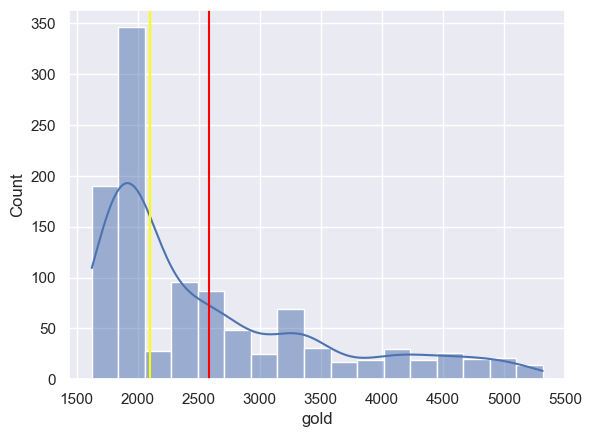

In [178]:
sns.histplot(data=df, x='gold', kde=True)
plt.axvline(df.gold.mean(), color="red")
plt.axvline(df.gold.median(), color="yellow")

In [179]:
px.line(data_frame=df, title='tickers adj. close price')

### normalizing

In [183]:
norm = df / df.iloc[0,:]
fig = px.line(norm)
fig.update_layout(title='stack movement observation by normalizing adj close prices , (daily cumulative return)',
                   xaxis_title='Date', 
                   yaxis_title='Normalized price')
fig.show()

### Rolling Statistics